# Model Testing Results

## Imports

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Import Result Data

In [50]:
arxiv_results_df = pd.read_parquet("../data/arxiv_all_results.parquet")
print(arxiv_results_df.head())

                                              Source  \
0  for about 20 years the problem of properties o...   
1  it is believed that the direct detection of gr...   
2  as a common quantum phenomenon , the tunneling...   
3  for the hybrid monte carlo algorithm ( hmc)@xc...   
4  recently it was discovered that feynman integr...   

                                           Reference  \
0  the short - term periodicities of the daily su...   
1  we study the detectability of circular polariz...   
2  starting from the wkb approximation , a new ba...   
3  we study a novel class of numerical integrator...   
4  new methods for obtaining functional equations...   

                                        bart_summary  \
0  The problem of properties of short - term chan...   
1  It is believed that the direct detection of gr...   
2  The tunneling through a potential barrier play...   
3  The hybrid monte carlo algorithm ( hmc)@xcite ...   
4  In the present paper we propose essentially

In [53]:
cnn_results_df = pd.read_parquet("../data/cnn_all_results.parquet")
print(cnn_results_df.head())

                                              Source  \
0  Ever noticed how plane seats appear to be gett...   
1  A drunk teenage boy had to be rescued by secur...   
2  Dougie Freedman is on the verge of agreeing a ...   
3  Liverpool target Neto is also wanted by PSG an...   
4  Bruce Jenner will break his silence in a two-h...   

                                           Reference  \
0  Experts question if  packed out planes are put...   
1  Drunk teenage boy climbed into lion enclosure ...   
2  Nottingham Forest are close to extending Dougi...   
3  Fiorentina goalkeeper Neto has been linked wit...   
4  Tell-all interview with the reality TV star, 6...   

                                        bart_summary  \
0  U.S consumer advisory group set up by Departme...   
1  Rahul Kumar, 17, clambered over enclosure fenc...   
2  Dougie Freedman is on the verge of agreeing a ...   
3  Fiorentina goalkeeper Neto is wanted by a numb...   
4  The former Olympian and reality TV star, 65

## ArXiv ROUGE Chart

In [ ]:
# 1. Calculate averages for all metrics
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
bart_means = [
    arxiv_results_df['bart_r1'].mean(), 
    arxiv_results_df['bart_r2'].mean(), 
    arxiv_results_df['bart_rL'].mean()
]
t5_means = [
    arxiv_results_df['t5_r1'].mean(), 
    arxiv_results_df['t5_r2'].mean(), 
    arxiv_results_df['t5_rL'].mean()
]
model_40k_means = [
    arxiv_results_df['model_40k_r1'].mean(), 
    arxiv_results_df['model_40k_r2'].mean(), 
    arxiv_results_df['model_40k_rL'].mean()
]
model_15k_means = [
    arxiv_results_df['model_15k_r1'].mean(), 
    arxiv_results_df['model_15k_r2'].mean(), 
    arxiv_results_df['model_15k_rL'].mean()
]

# 2. Set up the bar locations
x = np.arange(len(metrics))
width = 1 / 4

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, bart_means, width, label='BART', color='#3498db')
rects2 = ax.bar(x + width/6, t5_means, width, label='T5', color='#2ecc71')
rects3 = ax.bar(x + width/2, model_40k_means, width, label='Model 40k', color='#e74c3c')
rects4 = ax.bar(x + width, model_15k_means, width, label='Model 15k', color='#f39c12')

# 4. Add labels and styling
ax.set_ylabel('F1 Score (0 to 1)')
ax.set_title('Average ROUGE Score Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# 5. Add text labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

plt.tight_layout()
plt.savefig('../results/rouge_comparison_chart.png')
plt.show()

## ArXiv BERTScore Chart

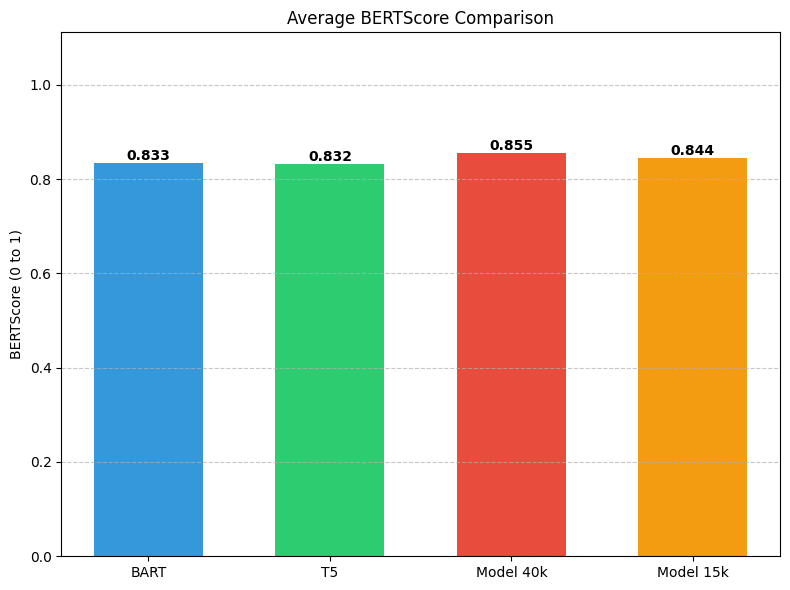

In [51]:
# 1. Calculate the means
bart_bertscore_mean = arxiv_results_df['bart_bertscore'].mean()
t5_bertscore_mean = arxiv_results_df['t5_bertscore'].mean()
model_40k_bertscore_mean = arxiv_results_df['model_40k_bertscore'].mean()
model_15k_bertscore_mean = arxiv_results_df['model_15k_bertscore'].mean()

# 2. Create the Bar Chart
plt.figure(figsize=(8, 6))
models = ['BART', 'T5', 'Model 40k', 'Model 15k']
means = [bart_bertscore_mean, t5_bertscore_mean, model_40k_bertscore_mean, model_15k_bertscore_mean]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = plt.bar(models, means, color=colors, width=0.6)

# 3. Add Labels and Styling
plt.ylabel('BERTScore (0 to 1)')
plt.title('Average BERTScore Comparison')
plt.ylim(0, max(means) * 1.3) # Add space for labels

# Add the values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../results/arxiv_bertscore_comparison_chart.png')
plt.show()

## ArXiv Compression Ratio Chart

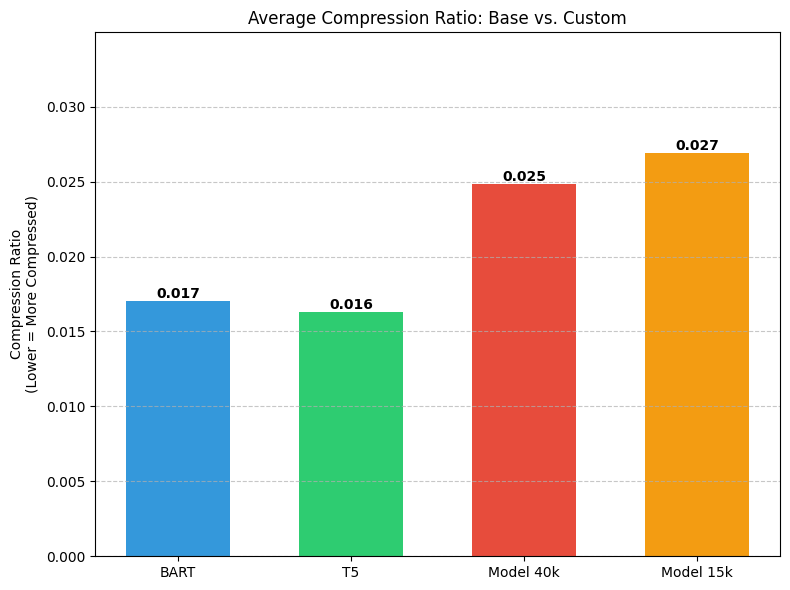

In [ ]:
# 1. Calculate the means
bart_cr_mean = arxiv_results_df['bart_cr'].mean()
t5_cr_mean = arxiv_results_df['t5_cr'].mean()
model_40k_cr_mean = arxiv_results_df['model_40k_cr'].mean()
model_15k_cr_mean = arxiv_results_df['model_15k_cr'].mean()

# 2. Create the Bar Chart
plt.figure(figsize=(8, 6))
models = ['BART', 'T5', 'Model 40k', 'Model 15k']
means = [bart_cr_mean, t5_cr_mean, model_40k_cr_mean, model_15k_cr_mean]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = plt.bar(models, means, color=colors, width=0.6)

# 3. Add Labels and Styling
plt.ylabel('Compression Ratio\n(Lower = More Compressed)')
plt.title('Average Compression Ratio: Base vs. Custom')
plt.ylim(0, max(means) * 1.3) # Add space for labels

# Add the values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../results/compression_ratio_comparison_chart.png')
plt.show()

## ArXiv Compression Ratio Box Plot

In [ ]:
# 1. Prepare data for Seaborn (Long format)
plot_df = arxiv_results_df.melt(value_vars=['bart_cr', 't5_cr', 'model_40k_cr', 'model_15k_cr'], 
                          var_name='Model', 
                          value_name='Compression Ratio')

# 2. Create the Box Plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Model', y='Compression Ratio', data=plot_df, palette=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])

# 3. Add Labels
plt.title('Distribution of Compression Ratios')
plt.ylabel('Compression Ratio (Summary Words / Source Words)')
plt.xlabel('Model Type')

plt.tight_layout()
plt.savefig('../results/compression_distribution_box.png')
plt.show()

## ArXiv Information Density Chart

In [ ]:
# 1. Calculate the mean density
bart_density_mean = arxiv_results_df['bart_density'].mean()
t5_density_mean = arxiv_results_df['t5_density'].mean()
model_40k_density_mean = arxiv_results_df['model_40k_density'].mean()
model_15k_density_mean = arxiv_results_df['model_15k_density'].mean()

# 2. Plotting
plt.figure(figsize=(8, 6))
labels = ['BART', 'T5', 'Model 40k', 'Model 15k']
densities = [bart_density_mean, t5_density_mean, model_40k_density_mean, model_15k_density_mean]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = plt.bar(labels, densities, color=colors, width=0.5)

# 3. Styling
plt.ylabel('Density Score (ROUGE-L / CR)')
plt.title('Model Efficiency: Information Density')
plt.grid(axis='y', linestyle=':', alpha=0.7)

# Add numeric labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/information_density_comparison_chart.png')
plt.show()

## ArXiv Information Density Scatter Plot

In [ ]:
plt.figure(figsize=(10, 7))

# Plot Base Model samples
plt.scatter(arxiv_results_df['bart_cr'], arxiv_results_df['bart_rL'], 
            alpha=0.5, label='BART', color='#3498db', s=80)

# Plot Custom Model samples
plt.scatter(arxiv_results_df['t5_cr'], arxiv_results_df['t5_rL'], 
            alpha=0.5, label='T5', color='#2ecc71', s=80)

plt.scatter(arxiv_results_df['model_40k_cr'], arxiv_results_df['model_40k_rL'], 
            alpha=0.5, label='Model 40k', color='#e74c3c', s=80)

plt.scatter(arxiv_results_df['model_15k_cr'], arxiv_results_df['model_15k_rL'], 
            alpha=0.5, label='Model 15k', color='#f39c12', s=80)

# Add "Target Zone" Annotation
plt.annotate('Highest Efficiency Zone', xy=(0.1, 0.5), xytext=(0.25, 0.6),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=10, fontweight='bold')

# Styling
plt.xlabel('Compression Ratio (Lower is more concise)')
plt.ylabel('ROUGE-L F1 Score (Higher is more accurate)')
plt.title('Accuracy vs. Compression: The Efficiency Frontier')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../results/accuracy_compression_scatter.png')
plt.show()

## CNN ROUGE Chart

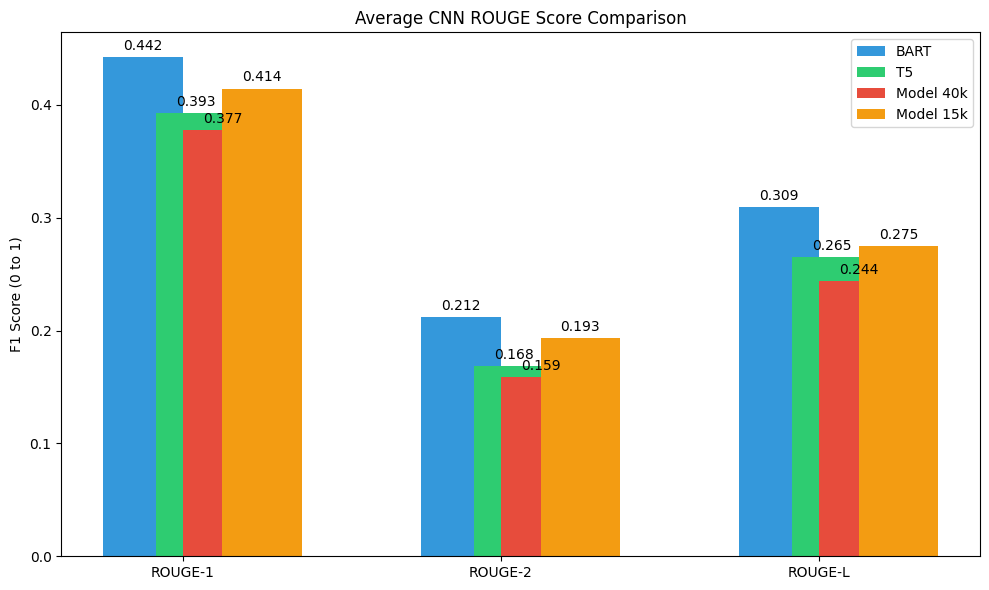

In [54]:
# 1. Calculate averages for all metrics
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
bart_means = [
    cnn_results_df['bart_r1'].mean(), 
    cnn_results_df['bart_r2'].mean(), 
    cnn_results_df['bart_rL'].mean()
]
t5_means = [
    cnn_results_df['t5_r1'].mean(), 
    cnn_results_df['t5_r2'].mean(), 
    cnn_results_df['t5_rL'].mean()
]
model_40k_means = [
    cnn_results_df['model_40k_r1'].mean(), 
    cnn_results_df['model_40k_r2'].mean(), 
    cnn_results_df['model_40k_rL'].mean()
]
model_15k_means = [
    cnn_results_df['model_15k_r1'].mean(), 
    cnn_results_df['model_15k_r2'].mean(), 
    cnn_results_df['model_15k_rL'].mean()
]

# 2. Set up the bar locations
x = np.arange(len(metrics))
width = 1 / 4

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, bart_means, width, label='BART', color='#3498db')
rects2 = ax.bar(x + width/6, t5_means, width, label='T5', color='#2ecc71')
rects3 = ax.bar(x + width/2, model_40k_means, width, label='Model 40k', color='#e74c3c')
rects4 = ax.bar(x + width, model_15k_means, width, label='Model 15k', color='#f39c12')

# 4. Add labels and styling
ax.set_ylabel('F1 Score (0 to 1)')
ax.set_title('Average CNN ROUGE Score Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# 5. Add text labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

plt.tight_layout()
plt.savefig('../results/cnn_rouge_comparison_chart.png')
plt.show()

## CNN BERTScore Chart

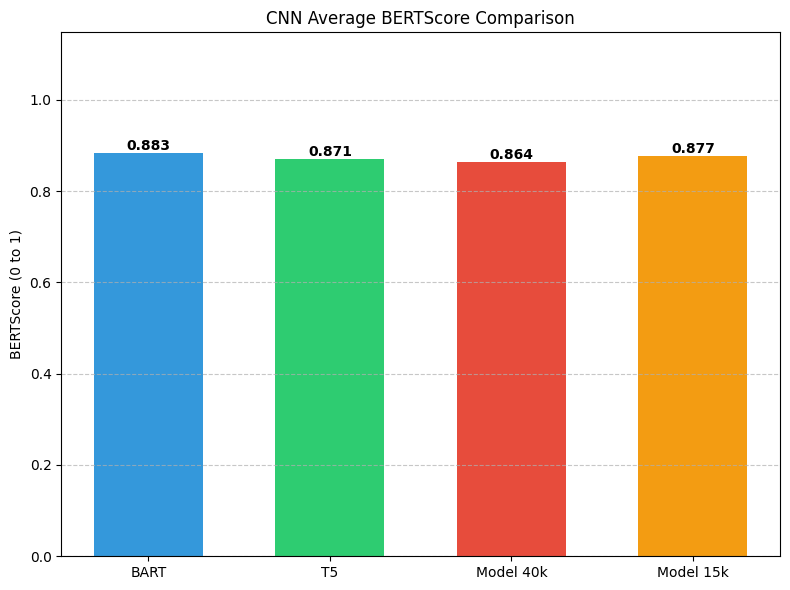

In [55]:
# 1. Calculate the means
bart_bertscore_mean = cnn_results_df['bart_bertscore'].mean()
t5_bertscore_mean = cnn_results_df['t5_bertscore'].mean()
model_40k_bertscore_mean = cnn_results_df['model_40k_bertscore'].mean()
model_15k_bertscore_mean = cnn_results_df['model_15k_bertscore'].mean()

# 2. Create the Bar Chart
plt.figure(figsize=(8, 6))
models = ['BART', 'T5', 'Model 40k', 'Model 15k']
means = [bart_bertscore_mean, t5_bertscore_mean, model_40k_bertscore_mean, model_15k_bertscore_mean]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = plt.bar(models, means, color=colors, width=0.6)

# 3. Add Labels and Styling
plt.ylabel('BERTScore (0 to 1)')
plt.title('CNN Average BERTScore Comparison')
plt.ylim(0, max(means) * 1.3) # Add space for labels

# Add the values on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../results/cnn_bertscore_comparison_chart.png')
plt.show()

## CNN Compression Ratio Chart

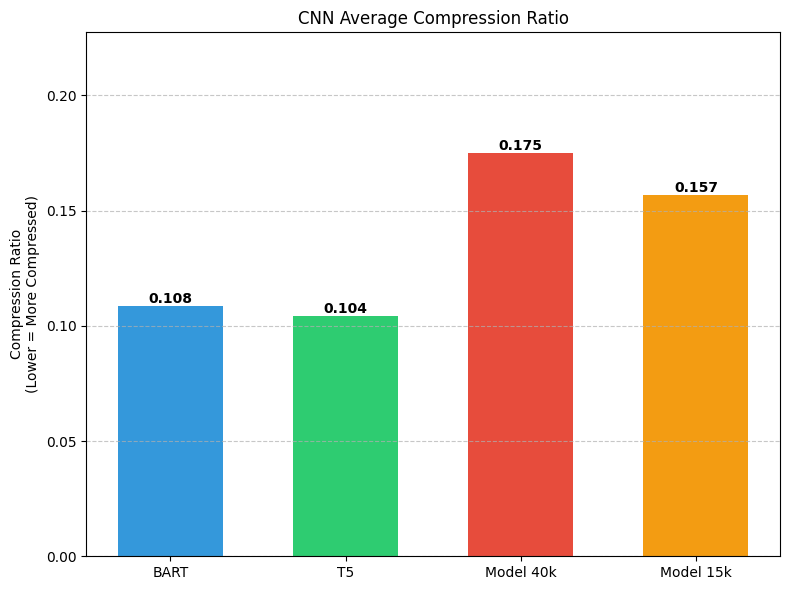

In [56]:
bart_cr_mean = cnn_results_df['bart_cr'].mean()
t5_cr_mean = cnn_results_df['t5_cr'].mean()
model_40k_cr_mean = cnn_results_df['model_40k_cr'].mean()
model_15k_cr_mean = cnn_results_df['model_15k_cr'].mean()

plt.figure(figsize=(8, 6))
models = ['BART', 'T5', 'Model 40k', 'Model 15k']
means = [bart_cr_mean, t5_cr_mean, model_40k_cr_mean, model_15k_cr_mean]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = plt.bar(models, means, color=colors, width=0.6)

plt.ylabel('Compression Ratio\n(Lower = More Compressed)')
plt.title('CNN Average Compression Ratio')
plt.ylim(0, max(means) * 1.3)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../results/cnn_compression_ratio_comparison_chart.png')
plt.show()

## CNN Compression Ratio Box Plot

/var/folders/60/b5613ft91lj31zhgk9phb9hr0000gn/T/ipykernel_12066/3955815503.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Model', y='Compression Ratio', data=plot_df, palette=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])


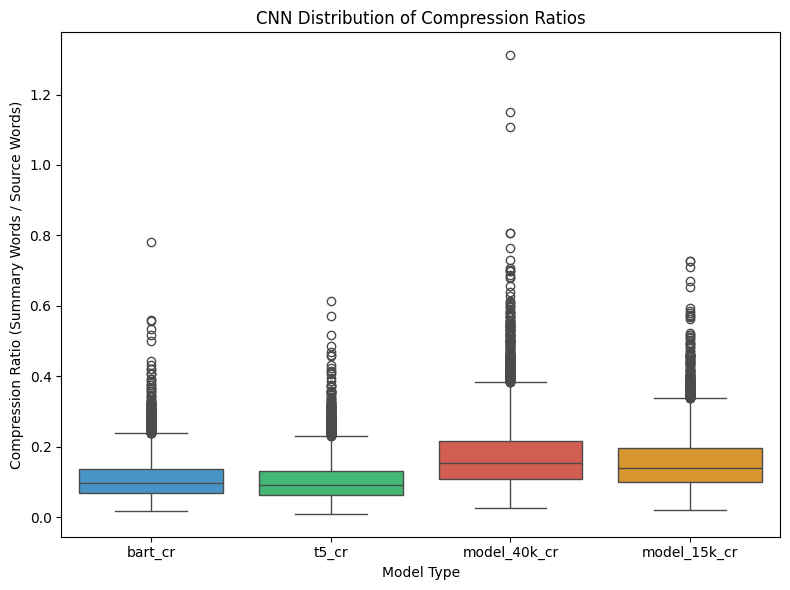

In [57]:
# 1. Prepare data for Seaborn (Long format)
plot_df = cnn_results_df.melt(value_vars=['bart_cr', 't5_cr', 'model_40k_cr', 'model_15k_cr'], 
                              var_name='Model', 
                              value_name='Compression Ratio')

# 2. Create the Box Plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Model', y='Compression Ratio', data=plot_df, palette=['#3498db', '#2ecc71', '#e74c3c', '#f39c12'])

# 3. Add Labels
plt.title('CNN Distribution of Compression Ratios')
plt.ylabel('Compression Ratio (Summary Words / Source Words)')
plt.xlabel('Model Type')

plt.tight_layout()
plt.savefig('../results/cnn_compression_distribution_box.png')
plt.show()

## CNN Information Density Chart

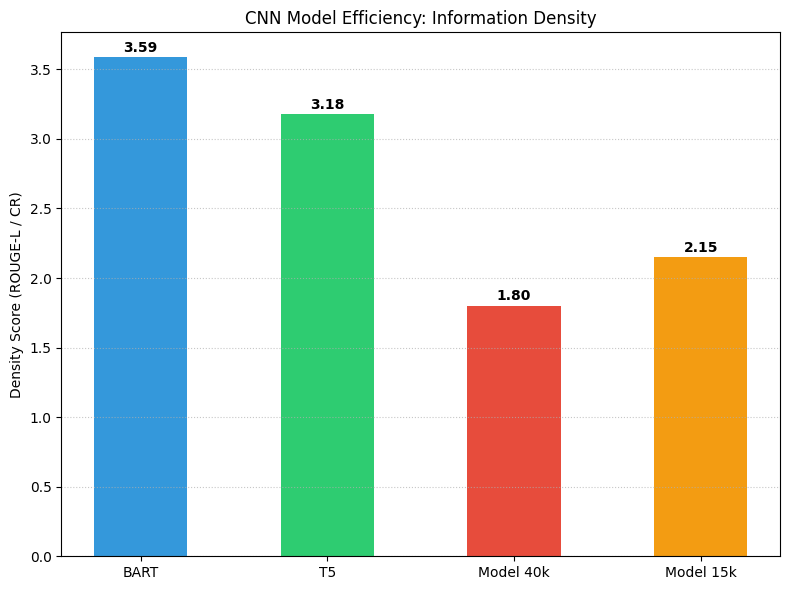

In [58]:
# 1. Calculate the mean density
bart_density_mean = cnn_results_df['bart_density'].mean()
t5_density_mean = cnn_results_df['t5_density'].mean()
model_40k_density_mean = cnn_results_df['model_40k_density'].mean()
model_15k_density_mean = cnn_results_df['model_15k_density'].mean()

# 2. Plotting
plt.figure(figsize=(8, 6))
labels = ['BART', 'T5', 'Model 40k', 'Model 15k']
densities = [bart_density_mean, t5_density_mean, model_40k_density_mean, model_15k_density_mean]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = plt.bar(labels, densities, color=colors, width=0.5)

# 3. Styling
plt.ylabel('Density Score (ROUGE-L / CR)')
plt.title('CNN Model Efficiency: Information Density')
plt.grid(axis='y', linestyle=':', alpha=0.7)

# Add numeric labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/cnn_information_density_comparison_chart.png')
plt.show()

## CNN Information Density Scatter Plot

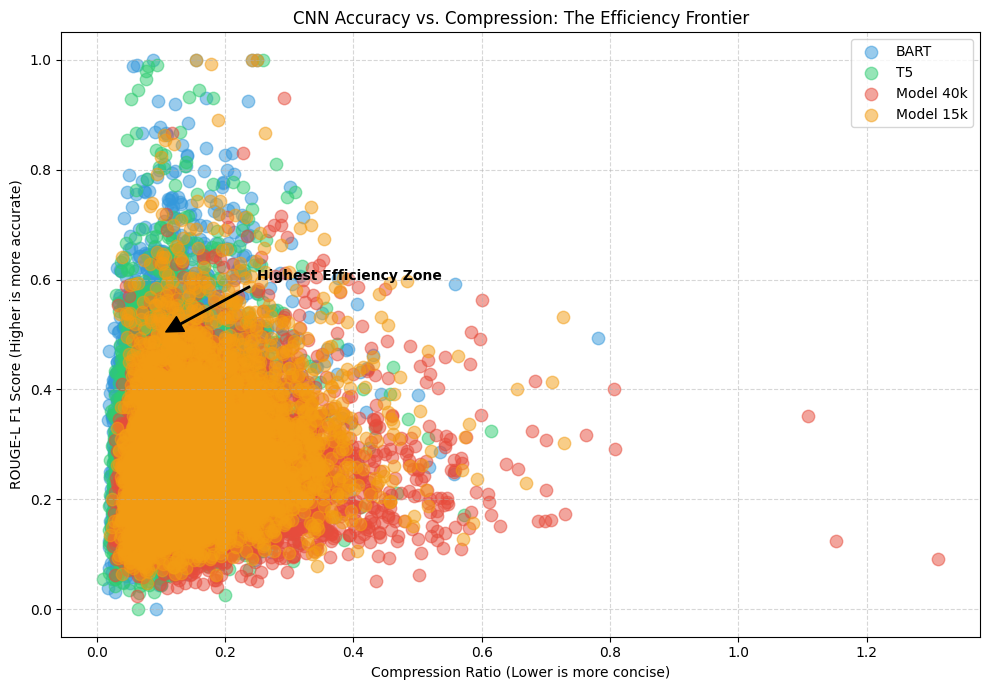

In [59]:
plt.figure(figsize=(10, 7))

plt.scatter(cnn_results_df['bart_cr'], cnn_results_df['bart_rL'], 
            alpha=0.5, label='BART', color='#3498db', s=80)

plt.scatter(cnn_results_df['t5_cr'], cnn_results_df['t5_rL'], 
            alpha=0.5, label='T5', color='#2ecc71', s=80)

plt.scatter(cnn_results_df['model_40k_cr'], cnn_results_df['model_40k_rL'], 
            alpha=0.5, label='Model 40k', color='#e74c3c', s=80)

plt.scatter(cnn_results_df['model_15k_cr'], cnn_results_df['model_15k_rL'], 
            alpha=0.5, label='Model 15k', color='#f39c12', s=80)

# Add "Target Zone" Annotation
plt.annotate('Highest Efficiency Zone', xy=(0.1, 0.5), xytext=(0.25, 0.6),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=10, fontweight='bold')

# Styling
plt.xlabel('Compression Ratio (Lower is more concise)')
plt.ylabel('ROUGE-L F1 Score (Higher is more accurate)')
plt.title('CNN Accuracy vs. Compression: The Efficiency Frontier')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../results/cnn_accuracy_compression_scatter.png')
plt.show()

## ROUGE CNN vs Arxiv Comparisons

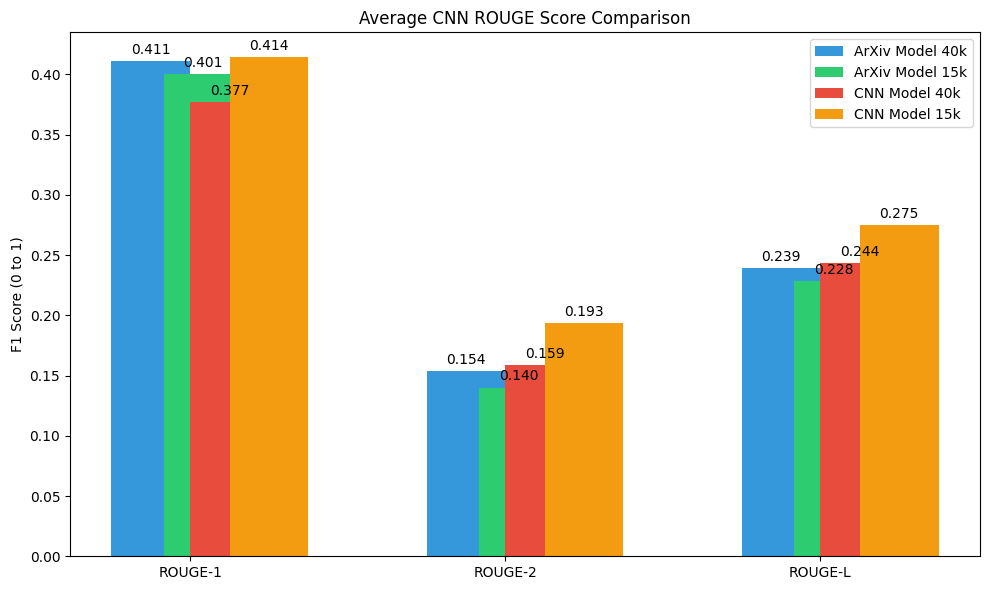

In [60]:
# 1. Calculate averages for all metrics
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
arxiv_model_40k_means = [
    arxiv_results_df['model_40k_r1'].mean(), 
    arxiv_results_df['model_40k_r2'].mean(), 
    arxiv_results_df['model_40k_rL'].mean()
]
arxiv_model_15k_means = [
    arxiv_results_df['model_15k_r1'].mean(), 
    arxiv_results_df['model_15k_r2'].mean(), 
    arxiv_results_df['model_15k_rL'].mean()
]
cnn_model_40k_means = [
    cnn_results_df['model_40k_r1'].mean(), 
    cnn_results_df['model_40k_r2'].mean(), 
    cnn_results_df['model_40k_rL'].mean()
]
cnn_model_15k_means = [
    cnn_results_df['model_15k_r1'].mean(), 
    cnn_results_df['model_15k_r2'].mean(), 
    cnn_results_df['model_15k_rL'].mean()
]

# 2. Set up the bar locations
x = np.arange(len(metrics))
width = 1 / 4

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, arxiv_model_40k_means, width, label='ArXiv Model 40k', color='#3498db')
rects2 = ax.bar(x + width/6, arxiv_model_15k_means, width, label='ArXiv Model 15k', color='#2ecc71')
rects3 = ax.bar(x + width/2, cnn_model_40k_means, width, label='CNN Model 40k', color='#e74c3c')
rects4 = ax.bar(x + width, cnn_model_15k_means, width, label='CNN Model 15k', color='#f39c12')

# 4. Add labels and styling
ax.set_ylabel('F1 Score (0 to 1)')
ax.set_title('Average CNN ROUGE Score Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()

# 5. Add text labels on top of bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)
autolabel(rects4)

plt.tight_layout()
plt.savefig('../results/cnn_vs_arxiv_rouge_comparison_chart.png')
plt.show()

## Compression Ratio CNN vs. Arxiv Comparison

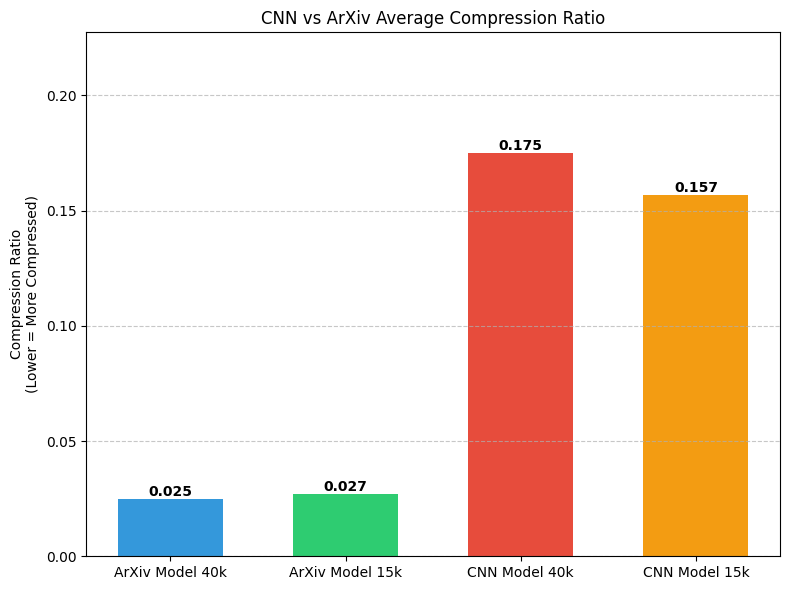

In [61]:
arxiv_model_40k_cr_mean = arxiv_results_df['model_40k_cr'].mean()
arxiv_model_15k_cr_mean = arxiv_results_df['model_15k_cr'].mean()
cnn_model_40k_cr_mean = cnn_results_df['model_40k_cr'].mean()
cnn_model_15k_cr_mean = cnn_results_df['model_15k_cr'].mean()

plt.figure(figsize=(8, 6))
models = ['ArXiv Model 40k', 'ArXiv Model 15k', 'CNN Model 40k', 'CNN Model 15k']
means = [arxiv_model_40k_cr_mean, arxiv_model_15k_cr_mean, cnn_model_40k_cr_mean, cnn_model_15k_cr_mean]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = plt.bar(models, means, color=colors, width=0.6)

plt.ylabel('Compression Ratio\n(Lower = More Compressed)')
plt.title('CNN vs ArXiv Average Compression Ratio')
plt.ylim(0, max(means) * 1.3)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.3f}', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../results/cnn_vs_arxiv_compression_ratio_comparison_chart.png')
plt.show()

## CNN vs ArXiv Information Density

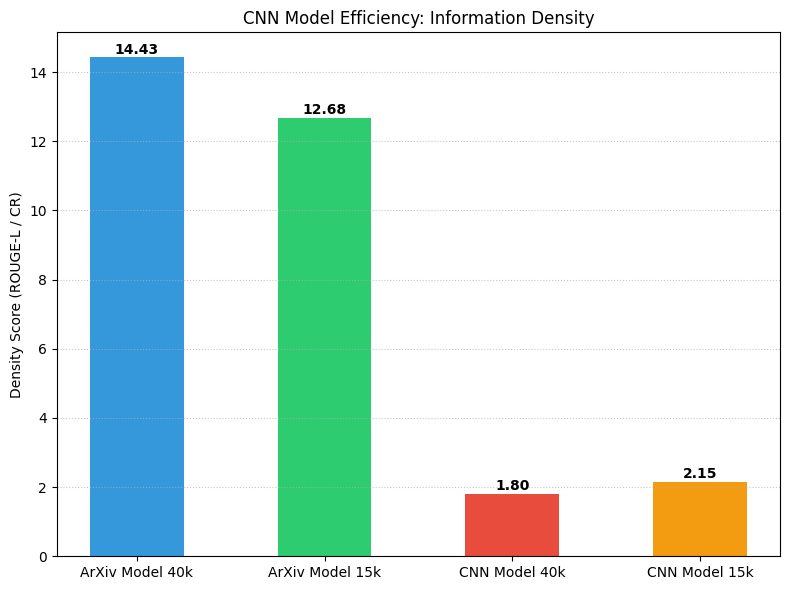

In [62]:
# 1. Calculate the mean density
arxiv_model_40k_density_mean = arxiv_results_df['model_40k_density'].mean()
arxiv_model_15k_density_mean = arxiv_results_df['model_15k_density'].mean()
cnn_model_40k_density_mean = cnn_results_df['model_40k_density'].mean()
cnn_model_15k_density_mean = cnn_results_df['model_15k_density'].mean()

# 2. Plotting
plt.figure(figsize=(8, 6))
labels = ['ArXiv Model 40k', 'ArXiv Model 15k', 'CNN Model 40k', 'CNN Model 15k']
densities = [arxiv_model_40k_density_mean, arxiv_model_15k_density_mean, cnn_model_40k_density_mean, cnn_model_15k_density_mean]
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

bars = plt.bar(labels, densities, color=colors, width=0.5)

# 3. Styling
plt.ylabel('Density Score (ROUGE-L / CR)')
plt.title('CNN Model Efficiency: Information Density')
plt.grid(axis='y', linestyle=':', alpha=0.7)

# Add numeric labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.02, f'{height:.2f}', 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/cnn_vs_arxiv_information_density_comparison_chart.png')
plt.show()

## CNN vs ArXiv Information Density Scatter Plot

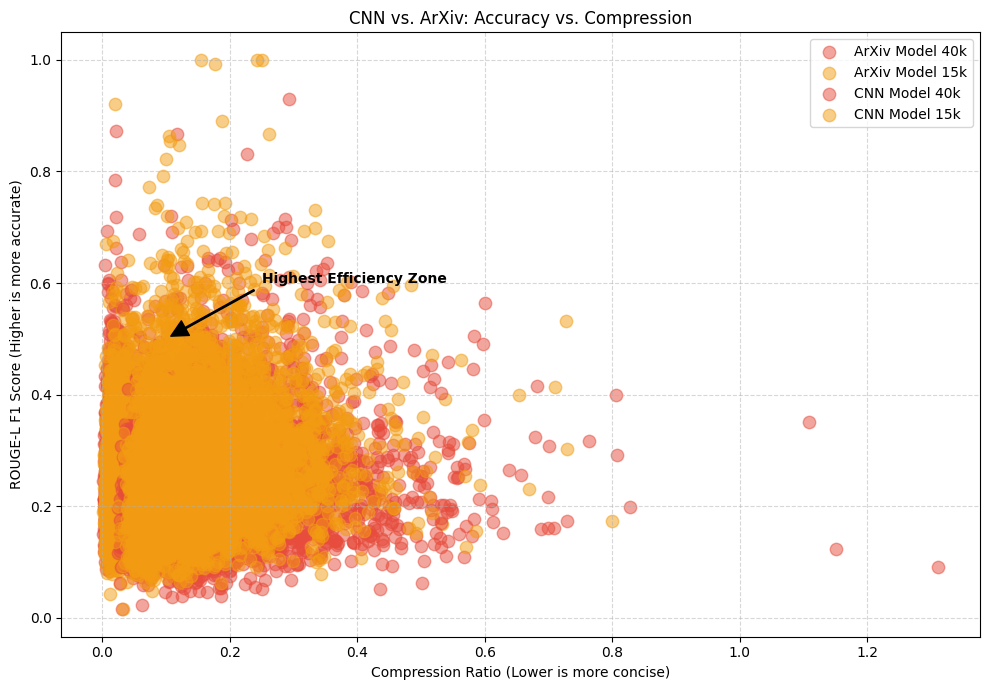

In [63]:
plt.figure(figsize=(10, 7))

plt.scatter(arxiv_results_df['model_40k_cr'], arxiv_results_df['model_40k_rL'], 
            alpha=0.5, label='ArXiv Model 40k', color='#e74c3c', s=80)

plt.scatter(arxiv_results_df['model_15k_cr'], arxiv_results_df['model_15k_rL'], 
            alpha=0.5, label='ArXiv Model 15k', color='#f39c12', s=80)

plt.scatter(cnn_results_df['model_40k_cr'], cnn_results_df['model_40k_rL'],
            alpha=0.5, label='CNN Model 40k', color='#e74c3c', s=80)    

plt.scatter(cnn_results_df['model_15k_cr'], cnn_results_df['model_15k_rL'],
            alpha=0.5, label='CNN Model 15k', color='#f39c12', s=80)

# Add "Target Zone" Annotation
plt.annotate('Highest Efficiency Zone', xy=(0.1, 0.5), xytext=(0.25, 0.6),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1),
             fontsize=10, fontweight='bold')

# Styling
plt.xlabel('Compression Ratio (Lower is more concise)')
plt.ylabel('ROUGE-L F1 Score (Higher is more accurate)')
plt.title('CNN vs. ArXiv: Accuracy vs. Compression')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../results/cnn_vs_arxiv_accuracy_compression_scatter.png')
plt.show()